## Pattern Recognition and Machine Learning - Assignment I
### Year 2025-2026- Semester II
### CCE2502
####  developed by - Adrian Muscat, 2026
---
### Write your name, ID Card Number below
Mirea Sacco 0173606L

---


In this assignment you will be developing Python code to experiment with the k-Nearest Neighbour (k-NN) predictive model.


All questions are graded and total to 100.
This assignment contributes to a maximum of 30% of the final study unit score. 

In case of any ideas or expected results obtained from literature, cite the proper publication. In general you should not cite blogs (If you do use blogs or AI tools, trace the original document and cite that)

Submit on VLE:
1. This jupyter notebook complete with answers to the questions (.ipynb)
2. A pdf copy of the same jupyter notebook with all cells executed
3. The completed and signed plagiarism and collusion form

All zipped into one file.

NOTE: before you save your final file, **reset the kernel and execute all the cells**.

## NOTE: 

This work is to be attempted individually. It is essential that the work you eventually submit and present for your assignment consists only of your own work; use of copied material will be treated as plagiarism or collusion. Discussion is only permitted on general issues, and it is absolutely forbidden to discuss specific details with anyone and/or share results.

Below are links to the Plagiarism and Collusion form:

https://www.um.edu.mt/media/um/docs/faculties/ict/mainfacultyofictfiles/PlagiarismForm.pdf

or at:
https://www.um.edu.mt/ict/students/formsguidelines/


In [1]:
# Execute this to record library versions installed on your system
import matplotlib
import numpy
import sklearn
import sys

print("Python version : ", sys.version)
print("numpy version : ", numpy.__version__)
print("sklearn version : ", sklearn.__version__)
print("matplotlib version : ", matplotlib.__version__)

Python version :  3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
numpy version :  2.4.2
sklearn version :  1.8.0
matplotlib version :  3.10.8


## This assignment consists of two tasks, each split into a  number of questions. Answer all questions.

# Task I: Selecting the neighbours and calculating probabilities
### For this task you are only allowed to use the following python modules (use of other modules will result in loss of marks)
1. **numpy**
2. **matplotlib.pyplot**

Considering a circle (hyper sphere in higher dimensions) predicting probabilities in classification and regression
1. Given ready made classification and regression algorithm, and an accuracy function
2. Load the two datasets
3. Train the two models, vary k from 1 to 21 and plot the accuracy vs k. which k maximizes accuracy?
4. Copy the function, rename it to RadiusNN and modify it such that the neighbours considered for regression or classification are those that are within the circle defined by the test point as the centre of the circle and radius, r,  which should be considered as a hyper-parameter of the model. We call call this model r-NN instead of k-NN.
5. train the two models and vary r and plot the accuracy vs r. which r maximises accuracy?
6. discuss (no more the 50 words) the choice between k and r, are the results as expected  

## Preamble : Binary k-NN classifier function
You will use the **predict_kNN_euclidian()** function to answer some of the questions
### DO NOT MODIFY the below CELL

In [2]:

# DO NOT MODIFY THIS CELL
import numpy as np

def predict_kNN_euclidian(k, X_train, y_train, X_query):
    """
    Inputs:
    ----------
    k : k nearest neighbours considered
    X_train : (MxN) feature array in n-dimensions,
                (M = number of examples, N = number of features)
    y_train : (M,) output labels in any dimension, typically 1-dimension
    X_query : (mxN) dimensional real array, m independent queries 
                    for one query shape is (1,2)
                    
    Outputs:
    --------
    Predictions for each instance in X_query, m-dimensional
    """
    def k_nearest_neighbour_euclidian(k, X_train, y_train, x_new):
        M = y_train.shape[0]
        dist = ((X_train-x_new)**2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M,1)), 
                             dist.reshape((M,1))), axis=1)
        DDs = DD[np.argsort(DD[:,3])]
        r = DDs[0:k,2].sum()
        c = 1 if r > k/2. else 0
        #return DDs[0:k,:], r, c 
        return c 
    
    m = X_query.shape[0]
    y = np.zeros(m)
    for i in range(m):
        y[i] = k_nearest_neighbour_euclidian(k, X_train, y_train, 
                                             X_query[i])
    return y

## First we load the dataset

In [3]:
# DO NOT MODIFY THIS CELL

import pickle
import numpy as np

with open("Task1_dataset_classification.pkl", "rb") as file:
    data = pickle.load(file)

X, y = data['X'], data['y']

assert (np.round(X.sum(),3), y.sum()) == (12.557, 501), "Checksum test failed"

In [4]:
#testing


## Question I_a: Generate a scatter plot of the 2-dimensional classification dataset [5 marks]

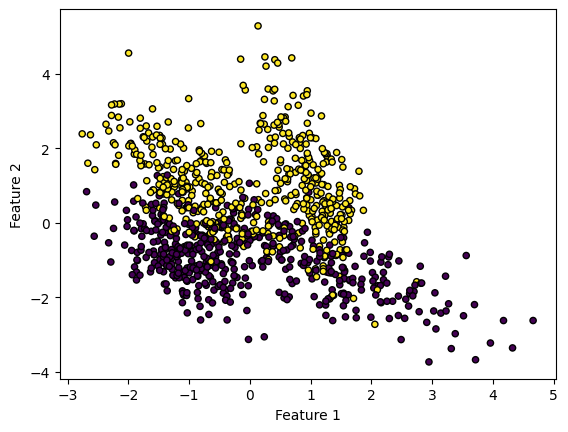

In [5]:
# add your code here
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y[:], edgecolor = 'k', s=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Question I_b : Complete the below function that partitions a dataset into two parts, the training and the testing sets. [5 marks]

In [6]:
def partition_dataset(X, y, s=0.8, shuffle=True, rng_seed=0):
    """
    Inputs:
    -------
    X : input features array of size MxN
    y : output label vector of size M
    s : fraction of dataset copied to training dataset
    shuffle : randomly shuffle dataset before splitting (True/false)
    seed : seed for random number generation

    Outputs:
    --------
    X_train : input features in training set, size (Ms)xN
    X_test  : input features in testing set, size (M(1-s)xN
    y_train : Output labels in training set, size Ms
    y_test  : Output labels in testing set, size M(1-s)
    """

    # add your code here
    len_data = len(y)
    partition = int(s * len_data)


    if shuffle:
        np.random.seed(rng_seed)
        a = list(range(len_data))
        np.random.shuffle(a)
        X_shuffle = X[a[:],:]
        y_shuffle = y[a[:]]
        X_train, y_train = X_shuffle[0:partition], y_shuffle[0:partition]
        X_test, y_test = X_shuffle[partition:], y_shuffle[partition:]
        
    else:
        X_train, y_train = X[0:partition], y[0:partition]
        X_test, y_test = X[partition:], y[partition:]

    
    return X_train, y_train, X_test, y_test
    

## Question I_c: Complete the below function to test the **partition_dataset()** function developed above and use the test function to test the partition_dataset() function [10 marks]

In [7]:
def test_partition_dataset_function():
    # write down some test examples split into train and test sets
    # (you can copy some examples from the dataset)
    # add your code here 

    sample_indexes = [48,84,773,28,356,992,957,738,562,428,539,247,248,629,803,254,632,479,463,578]
    len_indexes = len(sample_indexes)

    X_manual, y_manual = np.zeros((len_indexes,2)), np.zeros(len_indexes)
    j=0

    for i in sample_indexes:
        X_manual[j] = X[i, :]
        y_manual[j] = y[i]
        j += 1
    
    s = 0.8
    partition_manual = int(s*len(y_manual))

    X_manual_train = X_manual[:partition_manual]
    X_manual_test = X_manual[partition_manual:]
    y_manual_train = y_manual[:partition_manual]
    y_manual_test = y_manual[partition_manual:]

    # call partition_function
    # add your code here

    X_auto_train, y_auto_train, X_auto_test, y_auto_test = partition_dataset(X_manual,y_manual, shuffle=False)

    
    # compare splits to what is expected 
    # use assert keyword to output success or failure
    # add your code here
    
    assert (np.array_equal(X_manual_train, X_auto_train) and np.array_equal(y_manual_train, y_auto_train) and np.array_equal(X_manual_test, X_auto_test) and np.array_equal(y_manual_test, y_auto_test)), "test failed"
    print('test is successful')

    return 0

# use the test function to test the partition function   
# add your code here

test_partition_dataset_function()


test is successful


0

## Question I_d : choose k, from [1, 3, 5, ..., 19, 21], that maximises the accuracy metric. [5 marks]
Explain the methodolgy in no more than 50 words

In [8]:
# add your code here

def pred_accuracy(list1, list2):

	accuracy = (list1 == list2).mean()
	
	return accuracy

X_train, y_train, X_test, y_test = partition_dataset(X, y)
k_test = list(range(1, 22, 2))
k_accuracy = []

for k in k_test:
	y_predicted = predict_kNN_euclidian(k, X_train, y_train, X_test)
	k_accuracy.append(pred_accuracy(y_predicted, y_test))


k_max_accuracy = k_test[k_accuracy.index(max(k_accuracy))]
print('The k which maximises accuracy is k =', k_max_accuracy)


The k which maximises accuracy is k = 15


The function pred_accuracy will give the accuracy (from 0 up to 1) based on how many corresponding elements in 2 lists are equivalent. This function is then used to calculate the accuracy for each number of k when iterating through 1 up to 21. Then the maximum from the list of accuracies and its corresponding value of k is found.

## Question I_e: Complete the below function, **predict_kNN_radius()**, such that the neighbours considered for predicting the output are those that are within a circle defined by the query vector as the centre of the circle of radius r. We will call this model r-NN instead of k-NN. [10 marks]


In [9]:
def predict_kNN_radius(r, X_train, y_train, X_query):
    """
    Inputs:
    ----------
    r : r is the radius of the circle with centre X_query[i] that encloses the nearest neighbours
    X_train : (MxN) feature array in n-dimenions,
                (M = number of examples, N = number of features)
    y_train : (M,) output labels in any dimension, typically 1-dimension
    X_query : (mxN) dimensional real array, m independent queries 
                    for one query shape is (1,2)
                    
    Outputs:
    --------
    Predictions for each instance in X_query, m-dimensional
    """
    
    # below copy the code from predict_kNN_euclidian() and modify it for a r-NN classifier

    def r_nearest_neighbour_radius(r, X_train, y_train, x_new):
        M = y_train.shape[0]
        dist = ((X_train-x_new)**2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M,1)), 
                             dist.reshape((M,1))), axis=1)
        DDs = DD[np.argsort(DD[:,3])]
        in_range = 0
		
        for i in range(len(DDs)):			    
            if r >= DDs[i, 3]:			
                in_range+=1
				
            else:
                break

        q = DDs[0:in_range,2].sum()
        c = 1 if q > in_range/2. else 0
        #return DDs[0:k,:], q, c 
        return c

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
    m = X_query.shape[0]
    y = np.zeros(m)
    for i in range(m):
        y[i] = r_nearest_neighbour_radius(r, X_train, y_train, 
                                             X_query[i])
    
    return y

## Question I_f : Choose r that maximises the accuracy metric. [5 marks]

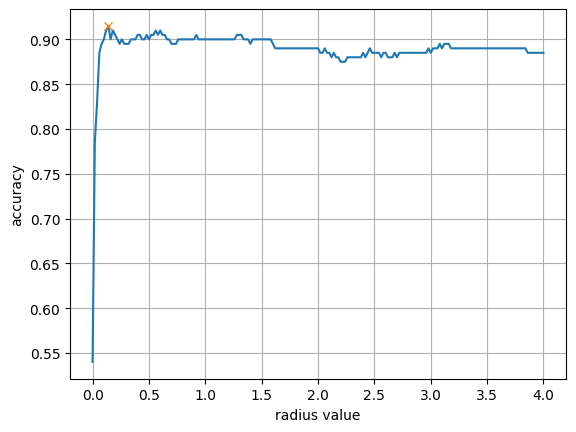

The maximum accuracy( 0.915 ) happens when the radius is equal to 0.14 . It is marked by the orange cross on the plot.


In [10]:
# add your code here
r_accuracy = []
radius_for_testing = np.linspace(0, 4, 201)

for i in radius_for_testing:
   yr_predicted = predict_kNN_radius(i, X_train, y_train, X_test)
      
   r_accuracy.append(pred_accuracy(yr_predicted, y_test))

r_max_accuracy = max(r_accuracy)
max_r = radius_for_testing[r_accuracy.index(r_max_accuracy)]


plt.plot(radius_for_testing, r_accuracy)
plt.plot(max_r, r_max_accuracy, 'x')
plt.xlabel('radius value')
plt.ylabel('accuracy')
plt.grid(True)
plt.show()

print('The maximum accuracy(', r_max_accuracy, ') happens when the radius is equal to', max_r,'. It is marked by the orange cross on the plot.')


## Question I_g: Add python code to both classifier functions (k-NN and r-NN)  such that the same functions return the probability of the class predicted. [5 marks]

i.e In the current implementation, the k-NN and r_NN functions return a vector whose elements are the predicted class for each query instance.

e.g. **y = [ 1, 0, 1, 1, 0, 0, 0]**

The modified function will, in addition, return the probability of the classes in y,

e.g **p = [0.876, 0.567, 0.902, 0.981, 0.654, 0.812, .765]**

In [11]:
# Copy the functions here and add your code
# Predict the output for a few query instances as a demonstration of the new functions
# explain using comments within the python code how the probability is computed

def predict_kNN_euclidian(k, X_train, y_train, X_query):

    def k_nearest_neighbour_euclidian(k, X_train, y_train, x_new):
        M = y_train.shape[0]
        dist = ((X_train-x_new)**2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M,1)), 
                             dist.reshape((M,1))), axis=1)
        DDs = DD[np.argsort(DD[:,3])]
        r = DDs[0:k,2].sum()
        prob_for_1 = r/k #this line calculated the probability of the class 1
        if r > k/2:
            c = 1 
            p = prob_for_1
        else:
            c=0
            p = 1 - prob_for_1 #this line will give the probability for class 0 since 1 and 0 are the only 2 classes, prob of class 1 + prob of class 0 = 1
        #return DDs[0:k,:], r, c 
        return c, p
    
    m = X_query.shape[0]
    y = np.zeros(m)
    p = np.zeros(m)
    for i in range(m):
        y[i], p[i]= k_nearest_neighbour_euclidian(k, X_train, y_train, 
                                             X_query[i])
    return y, p




def predict_kNN_radius(r, X_train, y_train, X_query):
    
    def r_nearest_neighbour_radius(r, X_train, y_train, x_new):
        M = y_train.shape[0]
        dist = ((X_train-x_new)**2).sum(axis=1)
        DD = np.concatenate((X_train, y_train.reshape((M,1)), 
                             dist.reshape((M,1))), axis=1)
        DDs = DD[np.argsort(DD[:,3])]
        in_range = 0
		
        for i in range(len(DDs)):			    
            if r >= DDs[i, 3]:			
                in_range+=1
				
            else:
                break

        q = DDs[0:in_range,2].sum()
        prob_for_1 = q/in_range
        if q > in_range/2:
            c = 1 
            p = prob_for_1
        else:
            c=0
            p= 1 - prob_for_1
        #return DDs[0:k,:], q, c 
        return c,p

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
    m = X_query.shape[0]
    y = np.zeros(m)
    p= np.zeros(m)
    for i in range(m):
        y[i], p[i] = r_nearest_neighbour_radius(r, X_train, y_train, 
                                             X_query[i])
    
    return y, p


In [12]:
X_testing, y_testing = np.zeros((20,2)), np.zeros(20)

j=0
for i in [48,84,773,28,356,992,957,738,562,428,539,247,248,629,803,254,632,479,463,578]:
    X_testing[j] = X[i, :]
    y_testing[j] = y[i]
    j+=1

X_train, y_train, X_test, y_test = partition_dataset(X_testing, y_testing, shuffle=False)

k_y_pred, k_prob = predict_kNN_euclidian(9, X_train, y_train, X_test)

r_y_pred, r_prob = predict_kNN_radius(2, X_train, y_train, X_test)

print('probability using the k-nn function ; ', k_prob)
print('probability using the r-nn function ; ', r_prob)

probability using the k-nn function ;  [0.88888889 0.55555556 0.55555556 0.66666667]
probability using the r-nn function ;  [1.  0.8 1.  0.5]


## Question I_h: Compare and contrast (in no more the 75 words) the results obtained for the k-NN and r-NN. Are the results as expected? [5 marks]

Using the written code above I tried multiple number for k and r. In most cases, the probability for r-NN was higher than the probability for k-NN. This result was expected since r-NN considers only the closer neighbours reguardless of the total number, while k-NN does not account for the distance to the neighbours, focusing only on a fixed number of nearest points.

# Task II: Time and space complexity of algorithm used to compute the nearest neighbours.
In this task you will make use of the sk-learn Machine Learning library to study complexity in k-NN models that compute the nearest neighbours using the brute force, the kD-Tree and the ball-Tree search algorithms and compare the results to the theoretical ones.

Notation:  
- M : number of instances (or examples) in the training set
- N : input (features) dimension

In this task you will set up experiments to compare the time and space complexity of all three algorithms.

Time complexity  : Measure time taken to complete a query 

Space complexity : The space in memory occupied by the dataset and/or tree and any other pertinent logic.

## Dataset

You will make use of the synthetic data generator algorithms in sk-learn. More specifically you will use **sklearn.datasets.make_classification()**.

The function is in the cell below. Use this function to generate datasets of various sizes and input dimensions (M and N) as required in your experiments.

In [13]:
from sklearn.datasets import make_classification

X, y = make_classification(
                    n_samples=1000,   # you will need to vary this in your experiment
                    n_features=2,     # you will need to vary this in your experiment
                    n_informative=2,  # this should equal n_features in your experiment
                    n_redundant=0,    # set this to 0
                    n_repeated=0,     # set this to 0
                    n_classes=2,      # set this to 2
                    n_clusters_per_class=1,  # set this to 1
                    weights=None,     # set this to NONE
                    flip_y=0.02,      # adds noise this determines how difficult the dataset is, optional
                    class_sep=0.5,    # separation of classes, larger values make classification easier, optional
                    hypercube=True,   # set to True
                    shift=0.0, scale=1.0, #set these to (0, 1.0)
                    shuffle=True,     # set this to True
                    random_state=0,   # set this to 0 or any other integer
                    )
X.shape, y.shape

((1000, 2), (1000,))

## k-Nearest Neighbour  Model

In your experiments you will use the **sklearn.neighbors.KNeighborsClassifier()** as the predictive model. This model has three built in search algorithms, (‘brute’, ‘ball_tree’, ‘kd_tree’). Below is the link to its API:

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


## Question II_a : Write down the theoretical time and space complexities for all three algorithms (‘brute’, ‘ball_tree’, ‘kd_tree’). [10 marks]

- MAX Number of words : 75, (one equation is equivalent to one word)
- Cite your sources (find the original sources instead of citing blogs, AI tools, etc)

#### brute
Going through all the data points, the time complexity is O(nm). The space complexity is O(nm).
#### ball_tree
The time complexity is O(log(m)) and space complexity is O(nm)
#### kd_tree
The time complexity is O(n log n + log m)  and space complexity is O(nm)

### Citations
Cs, C. (n.d.). KD Trees. https://www.cs.cornell.edu/courses/cs4780/2022sp/notes/LectureNotes19.html?utm_source=copilot.com 

Deep Dive on KNN: Understanding and Implementing the K-Nearest Neighbors Algorithm. (2025, October 12). Arize AI. https://arize.com/blog-course/knn-algorithm-k-nearest-neighbor/#:~:text=The%20time%20complexity%20of%20the,other%20point%20in%20the%20dataset. 

Ram, P., & Sinha, K. (2019). Revisiting kd-tree for Nearest Neighbor Search. Revisiting Kd-tree for Nearest Neighbor Search, 1378–1388. https://doi.org/10.1145/3292500.3330875

## Question II_b: Setup and run the experiments and plot the complexities against M and N. [30 marks]

- Provide a description of how you intend to set up your experiments, followed by the python code.
- You are allowed to use the following sk-learn functions (do not use any other module or function from sklearn):
  - **sklearn.model_selection.train_test_split()** to split the dataset
  - **sklearn.preprocessing.StandardScaler()** to scale input values (optional)
  - **sklearn.neighbors.KNeighborsClassifier()** is the model
  - **sklearn.metrics.accuracy_score()** to compute accuracy (optional)

### Write down (explain) your experimental set up here (Max number of words: 100)


The performance across varying sample sizes M and number of features N will be evaluated by the use of make_classification over brute force, KD-tree and Ball-Tree algorithm. The StanderScaler will be used to normalise the data to get more accurate results.

The time complexity will be measure by calculating the average time per query during the prediction of the test set with the average time of 5 runs. The space complexity will be measured using tracemalloc to calculate the change in memory before the algorithm is fit to the data and after.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import time
import tracemalloc

#this function will return the split and scaled dataset needed for testing
def create_dataset(m_val=2000, n_val=10, rnd = 0):
    X, y = make_classification(
                    n_samples=m_val,
                    n_features=n_val,
                    n_informative=n_val,
                    n_redundant=0,
                    n_repeated=0,  
                    n_classes=2,  
                    n_clusters_per_class=1,
                    weights=None,    
                    flip_y=0.02,      
                    class_sep=0.5,  
                    hypercube=True,
                    shift=0.0, scale=1.0, #set these to (0, 1.0)
                    shuffle=True,
                    random_state= rnd,
                    )
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

def pred_timing_space(X_train, y_train, X_test, algo):
    knn = KNeighborsClassifier(n_neighbors=4, algorithm=algo)

    tracemalloc.start()

    baseline, _ = tracemalloc.get_traced_memory()

    knn.fit(X_train, y_train)

    final, _ = tracemalloc.get_traced_memory()
    tracemalloc.stop() 
    actual_space = final - baseline

    start = time.perf_counter()
    knn.predict(X_test)
    end = time.perf_counter()

    total_time = end - start
    time_per_query = total_time / len(X_test)

    return total_time, actual_space

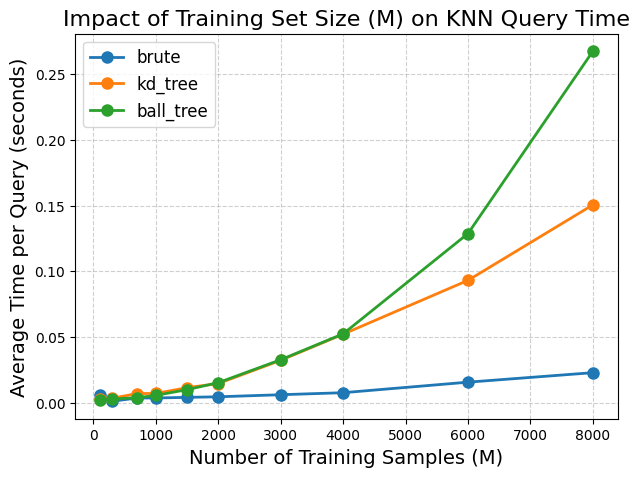

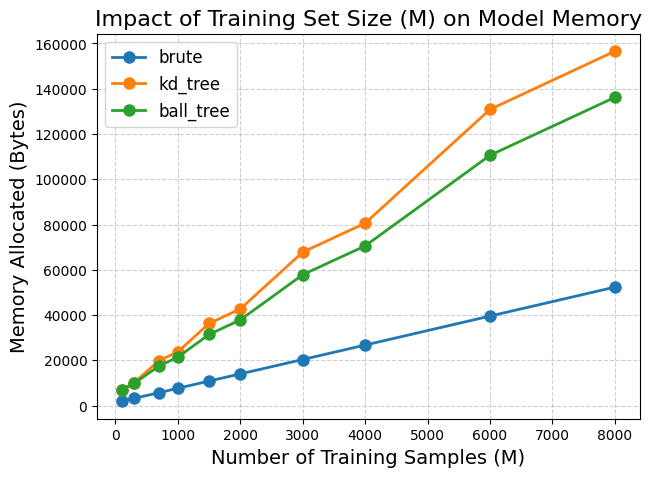

In [20]:
M_values = np.array([100, 300, 700, 1000, 1500, 2000, 3000, 4000, 6000, 8000])
N_values = np.array([20, 40, 60, 80, 100, 120, 140, 160])
algorithms = ['brute', 'kd_tree', 'ball_tree']
times_M = {alg: [] for alg in algorithms}
space_M = {alg: [] for alg in algorithms}

plt.figure(figsize=(7,5))

for alg in algorithms:

    for m in M_values:
        avg_time = 0
        avg_space = 0
        num_trials = 5
        for seed in range(num_trials):
            X_train, X_test, y_train, y_test = create_dataset(m_val = m, rnd = seed)

            timing, space = pred_timing_space(X_train, y_train, X_test, alg)

            avg_time += timing
            avg_space += space

        avg_space /= num_trials
        avg_time /= num_trials
        times_M[alg].append(avg_time)
        space_M[alg].append(avg_space)

    plt.plot(M_values, times_M[alg], label=alg, marker='o', linewidth=2, markersize=8)


plt.title('Impact of Training Set Size (M) on KNN Query Time', fontsize=16)
plt.xlabel('Number of Training Samples (M)', fontsize=14)
plt.ylabel('Average Time per Query (seconds)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)  # Add gridlines
plt.show()

plt.figure(figsize=(7,5))
for alg in algorithms:
    plt.plot(M_values, space_M[alg], label=alg, marker='o', linewidth=2, markersize=8)
plt.title('Impact of Training Set Size (M) on Model Memory', fontsize=16)
plt.xlabel('Number of Training Samples (M)', fontsize=14)
plt.ylabel('Memory Allocated (Bytes)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.show()


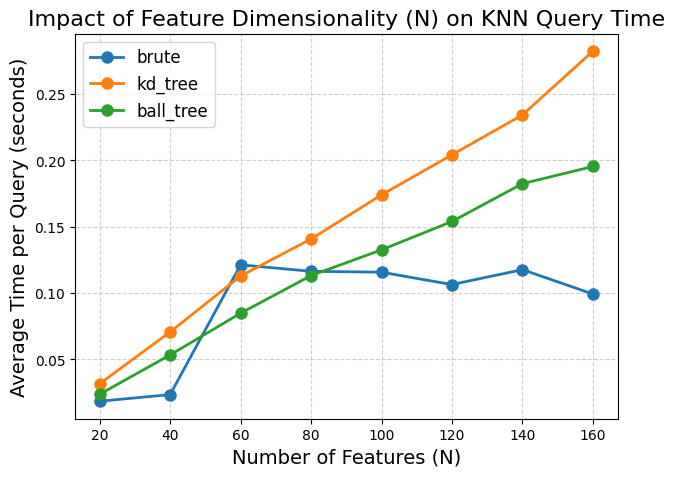

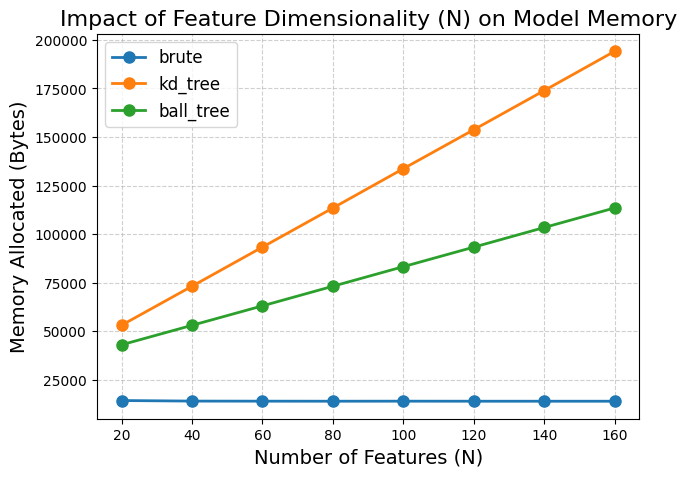

In [21]:
plt.figure(figsize=(7,5))

times_N = {alg: [] for alg in algorithms}
space_N = {alg: [] for alg in algorithms}

for alg in algorithms:

    for n in N_values:
        avg_time = 0
        avg_space = 0
        num_trials = 5
        for seed in range(num_trials):
            X_train, X_test, y_train, y_test = create_dataset(n_val = n, rnd = seed)

            timing, space = pred_timing_space(X_train, y_train, X_test, alg)

            avg_time += timing
            avg_space += space

        avg_space /= num_trials
        avg_time /= num_trials
        times_N[alg].append(avg_time)
        space_N[alg].append(avg_space)

    plt.plot(N_values, times_N[alg], label=alg, marker='o', linewidth=2, markersize=8)


plt.title('Impact of Feature Dimensionality (N) on KNN Query Time', fontsize=16)
plt.xlabel('Number of Features (N)', fontsize=14)
plt.ylabel('Average Time per Query (seconds)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.show()

plt.figure(figsize=(7,5))
for alg in algorithms:
    plt.plot(N_values, space_N[alg], label=alg, marker='o', linewidth=2, markersize=8)
plt.title('Impact of Feature Dimensionality (N) on Model Memory', fontsize=16)
plt.xlabel('Number of Features (N)', fontsize=14)
plt.ylabel('Memory Allocated (Bytes)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Question II_c: Discussion on results[10 marks]

Discuss whether and why the results were expected or otherwise.

#### Time Complexity
It was expected that the tree based algorithms exhibit logarithmic time complexity and grow slower than the linear, but this is not what the results show. 

The KD_tree and Ball_tree algorithm are seen to grow more in proportion to the Brute algorithm as the training size gets bigger. The spike of the tree based algorithms is a cause of the curse of dimensionality as the variable M gets bigger

#### Space Complexity
When varying M the graph, as expected, shows a linear path for all 3 algorithms. The tree structures take up more space in memory due to the data structure that the algorithm needs to build. This is in contrary to the brute algorithm which has no internal structure and has only a reference to the original dataset. 

When varying N, the memory footprint for the KD_tree and Ball_tree grow linearly as the number of features increases. This is expected behavior from theoretical space complexity of O(nm) for both of the tree based algorithms. On the other hand, the brute force algorithm maintains a fairly constant memory footprint as it does not create any new structure to hold the data.